In [2]:
import pandas as pd, numpy as np, joblib, os, warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, confusion_matrix
import matplotlib.pyplot as plt

try:
    import optuna
    from xgboost import XGBClassifier
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    print("✅ XGBoost and Optuna available")
except ImportError:
    print("❌ Run: pip install xgboost optuna")

✅ XGBoost and Optuna available


In [3]:
df = pd.read_csv("data/transactions_clean.csv", parse_dates=["ts"])
df = df.sort_values("ts").reset_index(drop=True)

def add_features(df):
    df = df.copy()
    df["log_amount"]           = np.log1p(df["amount"])
    df["avg_tx_amt_24h"]       = df["prev_24h_amt_card"] / (df["prev_24h_tx_count_card"] + 1e-3)
    df["velocity_ratio"]       = df["velocity_amt_1h"] / (df["avg_tx_amt_24h"] + 1e-3)
    df["amount_vs_24h_zscore"] = (df["amount"] - df["avg_tx_amt_24h"]) / (df["avg_tx_amt_24h"] + 1e-3)
    df["is_weekend"]           = df["dayofweek"].isin([5, 6]).astype(int)
    df["high_velocity_flag"]   = (df["prev_1h_tx_count_card"] > 3).astype(int)
    df["merchant_cat_rare"]    = 0
    return df

CUT   = int(len(df) * 0.80)
train = add_features(df.iloc[:CUT].copy())
valid = add_features(df.iloc[CUT:].copy())

NUM = ["amount","log_amount","prev_24h_tx_count_card","prev_24h_amt_card",
       "prev_1h_tx_count_card","velocity_amt_1h","avg_tx_amt_24h","velocity_ratio",
       "amount_vs_24h_zscore","hour","dayofweek",
       "is_international","is_night","is_weekend","merchant_cat_rare","high_velocity_flag"]
CAT  = ["merchant_cat","city","country","device_type","channel"]

X_tr = train[NUM + CAT]; y_tr = train["is_fraud"]
X_va = valid[NUM + CAT]; y_va = valid["is_fraud"]

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="unknown")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer([("num", num_pipe, NUM), ("cat", cat_pipe, CAT)])

pos_weight = (len(y_tr) - y_tr.sum()) / max(1, y_tr.sum())
print(f"scale_pos_weight = {pos_weight:.2f}  (handles class imbalance in XGBoost)")

scale_pos_weight = 22.24  (handles class imbalance in XGBoost)


In [4]:
def objective(trial):
    params = dict(
        n_estimators     = trial.suggest_int("n_estimators", 200, 500),
        max_depth        = trial.suggest_int("max_depth", 3, 7),
        learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample        = trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_lambda       = trial.suggest_float("reg_lambda", 0.0, 10.0),
        reg_alpha        = trial.suggest_float("reg_alpha", 0.0, 2.0),
        min_child_weight = trial.suggest_int("min_child_weight", 1, 10),
        scale_pos_weight = pos_weight,
        tree_method      = "hist",
        random_state     = 42,
        n_jobs           = -1,
    )
    pipe = Pipeline([("pre", preprocessor), ("xgb", XGBClassifier(**params))])
    pipe.fit(X_tr, y_tr)
    return average_precision_score(y_va, pipe.predict_proba(X_va)[:,1])

print("🔍 Starting Optuna (20 trials — increase n_trials for better results)...")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\n✅ Best PR-AUC : {study.best_value:.4f}")
print(f"   Best params  : {study.best_params}")

🔍 Starting Optuna (20 trials — increase n_trials for better results)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best PR-AUC : 0.9670
   Best params  : {'n_estimators': 453, 'max_depth': 3, 'learning_rate': 0.027068705393730682, 'subsample': 0.6924106883472467, 'colsample_bytree': 0.7947214579801138, 'reg_lambda': 7.823454905386581, 'reg_alpha': 1.9768034485584303, 'min_child_weight': 9}


In [5]:
best_params = {
    **study.best_params,
    "scale_pos_weight": pos_weight,
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = Pipeline([
    ("pre", preprocessor),
    ("xgb", XGBClassifier(**best_params)),
])
final_model.fit(X_tr, y_tr)
proba = final_model.predict_proba(X_va)[:,1]

from sklearn.metrics import roc_auc_score
print(f"✅ Final model trained")
print(f"   PR-AUC  : {average_precision_score(y_va, proba):.4f}")
print(f"   ROC-AUC : {roc_auc_score(y_va, proba):.4f}")

✅ Final model trained
   PR-AUC  : 0.9670
   ROC-AUC : 0.9957


⚖️  Optimal threshold : 0.070
   Minimum cost      : ₹53,350
   Recall at t*      : 0.9905
   Precision at t*   : 0.3853


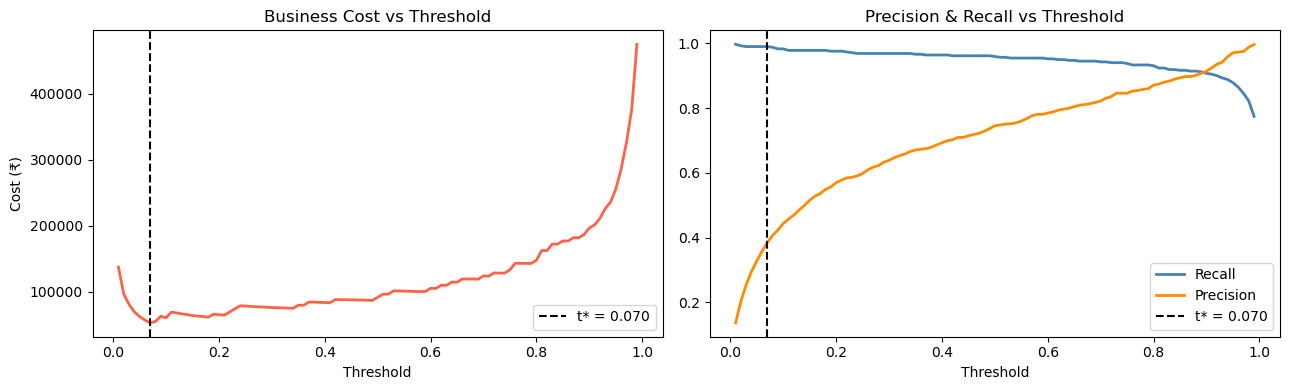

In [6]:
FN_COST = 5000
FP_COST = 50

thresholds = np.linspace(0.01, 0.99, 99)
costs, recalls, precisions = [], [], []

for t in thresholds:
    y_hat = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_va, y_hat).ravel()
    costs.append(fn * FN_COST + fp * FP_COST)
    recalls.append(tp / (tp + fn + 1e-9))
    precisions.append(tp / (tp + fp + 1e-9))

best_idx = np.argmin(costs)
T_STAR   = thresholds[best_idx]
print(f"⚖️  Optimal threshold : {T_STAR:.3f}")
print(f"   Minimum cost      : ₹{costs[best_idx]:,.0f}")
print(f"   Recall at t*      : {recalls[best_idx]:.4f}")
print(f"   Precision at t*   : {precisions[best_idx]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thresholds, costs, color="tomato", lw=2)
axes[0].axvline(T_STAR, color="black", linestyle="--", label=f"t* = {T_STAR:.3f}")
axes[0].set_title("Business Cost vs Threshold")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Cost (₹)")
axes[0].legend()

axes[1].plot(thresholds, recalls,    label="Recall",    color="steelblue", lw=2)
axes[1].plot(thresholds, precisions, label="Precision", color="darkorange", lw=2)
axes[1].axvline(T_STAR, color="black", linestyle="--", label=f"t* = {T_STAR:.3f}")
axes[1].set_title("Precision & Recall vs Threshold")
axes[1].set_xlabel("Threshold"); axes[1].legend()

plt.tight_layout(); plt.show()

In [7]:
os.makedirs("models", exist_ok=True)
bundle = {"model": final_model, "threshold": float(T_STAR)}
joblib.dump(bundle, "models/fraud_xgb.joblib")
print(f"✅ Model saved → models/fraud_xgb.joblib")
print(f"   Threshold stored : {T_STAR:.3f}")
print("\n→ Move to Notebook 5: Evaluation")

✅ Model saved → models/fraud_xgb.joblib
   Threshold stored : 0.070

→ Move to Notebook 5: Evaluation
